# Topic Modeling

## Overview
Topic modeling is an unsupervised machine learning technique that automatically discovers abstract "topics" that occur in a collection of documents. It helps organize, understand, and summarize large text collections.

## What is Topic Modeling?

### Core Concept:
- **Input:** Collection of documents
- **Process:** Algorithm finds patterns of co-occurring words
- **Output:** Topics (clusters of related words) and document-topic associations

### Real-World Analogy:
Imagine reading thousands of news articles. You'd naturally group them:
- **Topic 1:** "election", "vote", "candidate", "president" → Politics
- **Topic 2:** "team", "game", "score", "player" → Sports
- **Topic 3:** "market", "stock", "economy", "trade" → Finance

Topic modeling does this automatically!

## Popular Algorithms:

### 1. LDA (Latent Dirichlet Allocation)
- **Most popular** topic modeling algorithm
- Assumes documents are mixtures of topics
- Topics are mixtures of words
- **Probabilistic:** Each document has a probability distribution over topics

### 2. LSA/LSI (Latent Semantic Analysis/Indexing)
- Uses **matrix factorization** (SVD - Singular Value Decomposition)
- Faster than LDA
- Good for smaller datasets
- Captures semantic relationships

## How Topic Modeling Works:

### Assumptions:
1. Each document discusses multiple topics (in different proportions)
2. Each topic is characterized by a distribution over words
3. Words that appear together frequently belong to the same topic

### Example:
**Document:** "The president announced new economic policies affecting the stock market"

**Topic Distribution:**
- Politics: 60%
- Economy: 40%

## Applications:

### 1. Content Organization
- Group similar documents automatically
- Organize large document collections (legal docs, emails, articles)

### 2. Recommendation Systems
- Recommend articles based on topic similarity
- "Readers who liked this topic also liked..."

### 3. Trend Analysis
- Track how topics change over time
- Identify emerging trends in social media

### 4. Information Retrieval
- Improve search by understanding topic context
- Find documents about the same topic (even with different words)

### 5. Document Summarization
- Extract key topics from long documents
- Generate topic-based summaries

In [25]:
import pandas as pd 
import re   
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
from nltk.stem import PorterStemmer
from gensim.models import LsiModel
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

## Setup
Import necessary libraries including Gensim (specialized for topic modeling).

In [6]:
data = pd.read_csv('c:/Users/sidne/Projects/Introduction-to-NLP/news_articles.csv')

## Load Data
Load news articles dataset for topic modeling.

In [5]:
import os
print(os.getcwd())

c:\Users\sidne\Projects\Introduction-to-NLP


In [7]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


## Explore the Data

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


Check data structure and types.

In [13]:
articles = data['content']

## Extract Article Content
Focus on the text content for analysis.

In [14]:
# take the content of the article, lowercase and remove punctuation
articles = articles.astype(str)
articles = articles.str.lower().apply(lambda x: re.sub(r'[^\w\s]', '', x))  

# stop word removal
en_stopwords = set(stopwords.words('english'))  
articles = articles.apply(lambda x: ' '.join([word for word in word_tokenize(x) if word not in en_stopwords]))  

# tokenize
articles = articles.apply(lambda x: word_tokenize(x))

# stemming (done for speed)
ps = PorterStemmer()
articles = articles.apply(lambda x: [ps.stem(word) for word in x])

**Why preprocessing matters for topic modeling:**
- Reduces vocabulary size → Faster computation
- Removes noise → Clearer topics
- Normalizes variations → "running"/"runs"/"ran" → "run"

## Text Preprocessing Pipeline
Essential preprocessing steps for topic modeling:

1. **Lowercase:** Standardize text
2. **Remove Punctuation:** Focus on words, not symbols
3. **Remove Stop Words:** Eliminate common, uninformative words
4. **Tokenization:** Split into individual words
5. **Stemming:** Reduce words to root form (faster alternative to lemmatization)

In [15]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

## View Preprocessed Text
Each article is now a list of preprocessed tokens.

In [16]:
dict = corpora.Dictionary(articles)
print(dict)

Dictionary<8691 unique tokens: ['10', '100', '108', '15', '155']...>


The dictionary contains the mapping of words to numerical IDs.

## Create Dictionary
Build a vocabulary mapping words to unique IDs.

In [17]:
doc_term = [dict.doc2bow(article) for article in articles]

## Create Document-Term Matrix
Convert each document to bag-of-words representation: (word_id, frequency) pairs.

In [18]:
print(doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 2), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 3), (24, 2), (25, 4), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 2), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 2), (48, 2), (49, 1), (50, 2), (51, 2), (52, 1), (53, 1), (54, 2), (55, 1), (56, 2), (57, 6), (58, 1), (59, 1), (60, 1), (61, 4), (62, 2), (63, 1), (64, 1), (65, 2), (66, 1), (67, 1), (68, 1), (69, 1), (70, 5), (71, 4), (72, 1), (73, 1), (74, 1), (75, 2), (76, 2), (77, 1), (78, 2), (79, 2), (80, 1), (81, 1), (82, 1), (83, 4), (84, 2), (85, 1), (86, 1), (87, 3), (88, 1), (89, 3), (90, 1), (91, 2), (92, 3), (93, 6), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 2), (104, 5), (105, 1), (106, 2), (107, 1), (108, 1), (109, 3), (110, 4)

This sparse representation is efficient for large corpora.

In [19]:
num_topics = 2

---

## Part 1: LDA (Latent Dirichlet Allocation)

### Set Number of Topics
Start with 2 topics as an example.

In [20]:
lda_model = gensim.models.LdaModel(corpus=doc_term, id2word=dict, num_topics=num_topics)

## Build LDA Model
Train the LDA model to discover topics.

In [21]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.017*"mr" + 0.012*"said" + 0.005*"trump" + 0.004*"one" + 0.004*"would"'),
 (1,
  '0.017*"mr" + 0.017*"said" + 0.006*"trump" + 0.005*"would" + 0.005*"state"')]

**Interpreting Topics:**
- Each line represents one topic
- Numbers are weights (higher = more important to topic)
- Words with high weights characterize the topic
- You must interpret/label topics based on the words

## View LDA Topics
Each topic shows the top words with their weights (importance to the topic).

In [24]:
lsa_model = LsiModel(corpus=doc_term, id2word=dict, num_topics=num_topics)
print(lsa_model.print_topics(num_topics=num_topics, num_words=5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]


**LSA vs LDA:**
- **LSA:** Faster, deterministic, uses SVD
- **LDA:** Probabilistic, often more interpretable topics
- Both need you to specify number of topics

---

## Part 2: LSA (Latent Semantic Analysis)
An alternative approach using matrix factorization.

In [26]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics in range(min_topics, max_topics+1):
    model = LsiModel(doc_term, num_topics=num_topics, id2word=dict, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dict, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

---

## Part 3: Finding Optimal Number of Topics

The hardest part of topic modeling: **How many topics should we use?**

### Coherence Score:
- Measures how semantically similar the top words in topics are
- Higher coherence = better, more interpretable topics
- We'll test different numbers of topics and compare coherence

## Train Models with Different Topic Counts
Test from 2 to 10 topics.

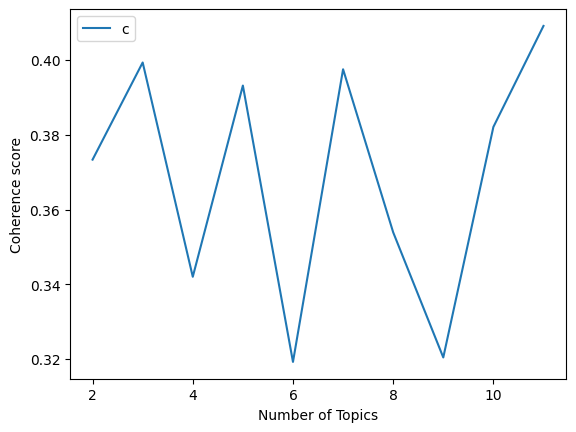

In [27]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

**How to choose:**
- Look for an "elbow" in the curve
- Peak coherence score
- Balance between coherence and interpretability
- Domain knowledge (e.g., if you know there are ~5 categories)

## Visualize Coherence Scores
Plot coherence vs. number of topics.

In [28]:
final_n_topics = 3
lsamodel_f = LsiModel(doc_term, num_topics=final_n_topics, id2word=dict)

## Key Takeaways:

### Topic Modeling Process:
1. **Preprocess:** Clean, tokenize, remove stop words, stem/lemmatize
2. **Create Dictionary & Corpus:** Convert to numerical representation
3. **Choose Algorithm:** LDA (probabilistic) or LSA (matrix factorization)
4. **Determine Topic Count:** Use coherence scores + domain knowledge
5. **Interpret Topics:** Label topics based on top words

### Best Practices:
- **Preprocessing is crucial:** Bad preprocessing = meaningless topics
- **Experiment:** Try different numbers of topics
- **Interpret:** Topics need human interpretation and labeling
- **Iterate:** Adjust preprocessing and parameters if topics don't make sense
- **Validate:** Check if topics align with known categories (if available)

### Common Pitfalls:
- ❌ Too few topics: Overly broad, mixed topics
- ❌ Too many topics: Redundant, overly specific topics
- ❌ Poor preprocessing: Topics dominated by common words
- ❌ Small dataset: Need sufficient documents for meaningful topics

### Applications Recap:
- Content organization and categorization
- Document recommendation
- Trend analysis over time
- Search and information retrieval
- Understanding large document collections

### Next Steps:
- Try LDA visualization (pyLDAvis library)
- Experiment with bigrams/trigrams in preprocessing
- Fine-tune hyperparameters (alpha, beta in LDA)
- Apply to domain-specific corpus
- Use topics as features for classification

## Build Final Model
Based on coherence analysis, choose optimal number of topics (e.g., 3).